<a href="https://colab.research.google.com/github/lavaeagle2/colab/blob/ml-practise-and-models/Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Step 2: Create a simple dataset
# -----------------------------------------
# 2 features so we can visualize easily
X, y = make_classification(n_samples=300,
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           n_clusters_per_class=1,
                           random_state=42)

In [ ]:
X

array([[ 7.33245541e-01, -1.43100684e+00],
       [ 6.56042914e-01,  8.42840539e-01],
       [ 5.37983123e-01, -2.05654971e+00],
       [ 1.28930785e+00, -7.90228359e-02],
       [ 7.20124125e-01,  9.77236854e-01],
       [ 5.61991851e-01, -1.63579119e+00],
       [ 2.27397878e+00, -6.75681514e-01],
       [ 1.56522694e+00,  2.08303420e+00],
       [ 1.21316626e+00,  1.62063670e+00],
       [ 1.28650510e+00, -4.69634644e-01],
       [ 1.28417180e+00, -9.22700896e-01],
       [ 8.22079523e-01, -1.59515966e+00],
       [ 2.72539489e-01,  1.51006394e+00],
       [ 2.42717743e+00, -3.64402467e-01],
       [ 2.63173891e-01,  8.09743991e-01],
       [ 1.39445338e+00, -4.42585367e-01],
       [ 1.32068778e+00,  2.90052459e-01],
       [ 9.05809576e-01, -1.41622254e+00],
       [ 5.68113684e-01, -1.65580986e+00],
       [ 1.19954708e+00, -3.98932506e-01],
       [ 6.93330338e-01,  1.63002545e+00],
       [ 7.28891503e-01, -1.55042626e+00],
       [ 6.32579249e-01, -1.65797012e+00],
       [ 2.

In [ ]:
y

array([0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1])

In [ ]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X,                                                    y,
                                                    test_size=0.3,
                                                    random_state=42)

In [ ]:
# -----------------------------------------
# Step 3: Train a WEAK model (Decision Stump)
# -----------------------------------------
# A stump = very small tree (max_depth=1)
weak_model = DecisionTreeClassifier(max_depth=1)
weak_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1)

In [ ]:
# Prediction
weak_pred = weak_model.predict(X_test)

print("Weak Model Accuracy:", accuracy_score(y_test, weak_pred))

Weak Model Accuracy: 0.9222222222222223


In [ ]:
# -----------------------------------------
# Step 4: Train AdaBoost (combines many weak models)
# -----------------------------------------
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner
    n_estimators=50,  # number of weak models
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)

In [ ]:
# Prediction
ada_pred = ada_model.predict(X_test)

print("Strong Model (AdaBoost) Accuracy:", accuracy_score(y_test, ada_pred))

Strong Model (AdaBoost) Accuracy: 0.9555555555555556


In [ ]:
# -----------------------------------------
# Step 5: Visualize decision boundaries
# -----------------------------------------

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()

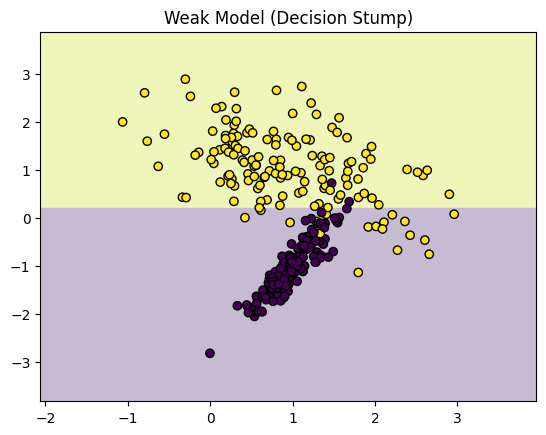

In [ ]:
# Plot weak model
plot_decision_boundary(weak_model, X, y, "Weak Model (Decision Stump)")


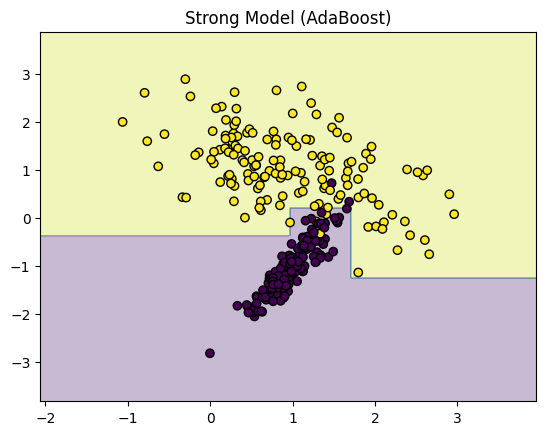

In [ ]:
# Plot strong model
plot_decision_boundary(ada_model, X, y, "Strong Model (AdaBoost)")

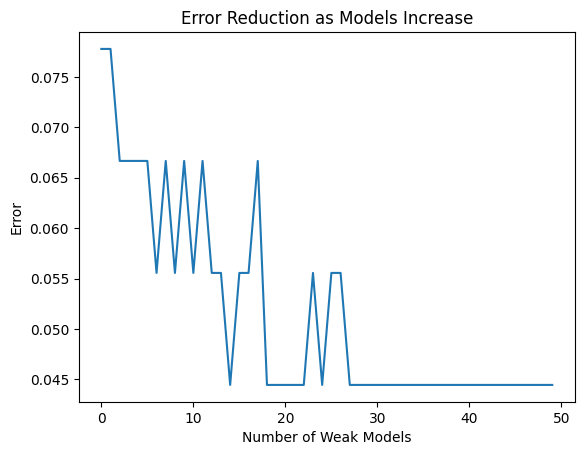

In [ ]:
# -----------------------------------------
# Step 6: Show learning improvement
# -----------------------------------------
# Track performance as more weak learners are added

errors = []

for y_pred in ada_model.staged_predict(X_test):
    errors.append(1 - accuracy_score(y_test, y_pred))

plt.plot(errors)
plt.title("Error Reduction as Models Increase")
plt.xlabel("Number of Weak Models")
plt.ylabel("Error")
plt.show()

In [ ]:
# -----------------------------------------
# FINAL INSIGHT
# -----------------------------------------
print("\nKey Insight:")
print("One weak model = poor accuracy")
print("Many weak models combined = strong performance (AdaBoost)")


Key Insight:
One weak model = poor accuracy
Many weak models combined = strong performance (AdaBoost)
